In [2]:
!python main.py

EMG shape: torch.Size([50000, 800])
Figure(4000x2000)
0: accept new source.
Figure(4000x2000)
1: accept new source.
Figure(4000x2000)
2: accept new source.
Figure(4000x2000)
3: accept new source.
Figure(4000x2000)
4: accept new source.
5: reject repeat source.
Figure(4000x2000)
6: accept new source.
7: reject low silhouette source.
Figure(4000x2000)
8: accept new source.
9: reject low silhouette source.
10: reject low silhouette source.
11: reject low silhouette source.
12: reject low silhouette source.
Figure(4000x2000)
13: accept new source.
14: reject low silhouette source.
Figure(4000x2000)
15: accept new source.
16: reject low silhouette source.
17: reject low silhouette source.
18: reject low silhouette source.
19: reject low silhouette source.
20: reject low silhouette source.
21: reject low silhouette source.
22: reject low silhouette source.
23: reject low silhouette source.
24: reject low silhouette source.
25: reject low silhouette source.
26: reject low silhouette source.
2

In [3]:
import pickle

# Make sure to use a Path object or a string path to the file
from pathlib import Path

file_path = Path("data\input\emg.pkl")

with open(file_path, "rb") as f:
    dictionary_result = pickle.load(f)

# Now you can access the keys/values in dictionary_result
print(dictionary_result.keys())

print(dictionary_result['silhouettes'])
print(dictionary_result['timestamps'][0])
print(dictionary_result['source'][0])
print(dictionary_result['source_type'])

dict_keys(['silhouettes', 'timestamps', 'source', 'RoA', 'filters', 'fr', 'cov', 'best_exp', 'source_type'])
[tensor(0.9873, device='cuda:0', dtype=torch.float64), tensor(0.9903, device='cuda:0', dtype=torch.float64), tensor(0.9809, device='cuda:0', dtype=torch.float64), tensor(0.9593, device='cuda:0', dtype=torch.float64), tensor(0.9263, device='cuda:0', dtype=torch.float64), tensor(0.8832, device='cuda:0', dtype=torch.float64), tensor(0.8752, device='cuda:0', dtype=torch.float64), tensor(0.9638, device='cuda:0', dtype=torch.float64), tensor(0.9604, device='cuda:0', dtype=torch.float64)]
tensor([23923, 24109, 24197, 24277, 25580, 25765, 36201, 36248, 36862, 37353,
        37422, 37701, 37861, 38305, 38647, 39556, 40410, 41017, 41313, 41605,
        42090], device='cuda:0')
[[-0.04720068]
 [-0.07122184]
 [ 0.26267397]
 ...
 [ 0.38243982]
 [ 0.38131976]
 [ 0.4639229 ]]
['good', 'good', 'good', 'good', 'good', 'repeat', 'good', 'bad', 'good', 'bad', 'bad', 'bad', 'bad', 'good', 'bad', 'g

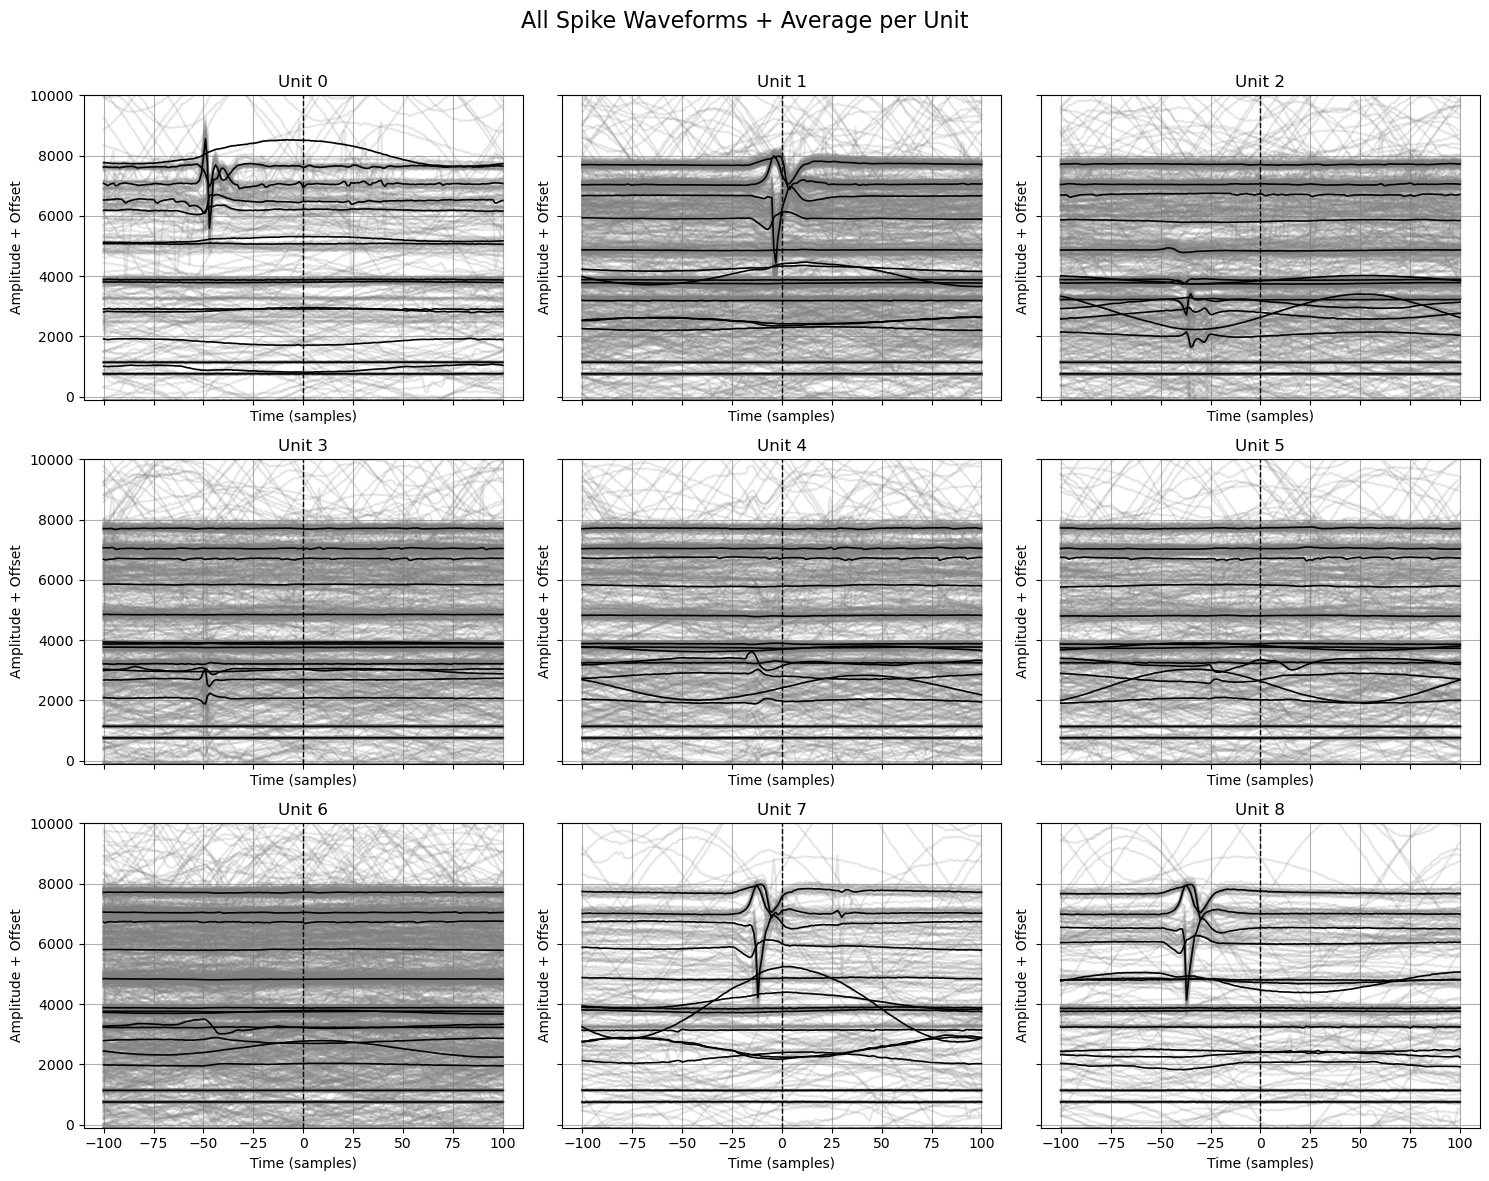

In [6]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
import math

data = loadmat('data\input\emg.mat')

emg = data['emg']
num_units = len(dictionary_result['timestamps'])
window = 100
num_channels, total_time = emg.shape
time_axis = np.arange(-window, window + 1)

# Layout for subplots
cols = 3
rows = math.ceil(num_units / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 4), sharex=True, sharey=True)
axes = axes.flatten()

for unit_idx in range(num_units):
    timestamps = dictionary_result['timestamps'][unit_idx].cpu().numpy()
    snippets = []

    for t in timestamps:
        if t - window >= 0 and t + window < total_time:
            snippet = emg[:, t - window : t + window + 1]
            snippets.append(snippet)

    ax = axes[unit_idx]

    if len(snippets) == 0:
        ax.set_title(f"Unit {unit_idx} - No valid spikes")
        continue

    snippets = np.stack(snippets)  # shape: (n_spikes, 16, 101)
    avg_waveform = snippets.mean(axis=0)  # shape: (16, 101)

    # Plot all waveforms (gray, semi-transparent)
    for s in range(snippets.shape[0]):
        for ch in range(num_channels):
            ax.plot(time_axis, snippets[s, ch] + ch * 500, color='gray', alpha=0.2)

    # Plot average waveform (black)
    for ch in range(num_channels):
        ax.plot(time_axis, avg_waveform[ch] + ch * 500, color='black', linewidth=1.2)

    ax.axvline(x=0, color='k', linestyle='--', linewidth=1)
    ax.set_title(f"Unit {unit_idx}")
    ax.set_xlabel("Time (samples)")
    ax.set_ylabel("Amplitude + Offset")
    ax.grid(True)
    ax.set_ylim([-100, 10000])

# Hide unused axes if any
for i in range(num_units, len(axes)):
    fig.delaxes(axes[i])

plt.suptitle("All Spike Waveforms + Average per Unit", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()
